**Prerequisites** \
pip install gensim pandas scikit-learn numpy matplotlib seaborn scipy


In [1]:
# Imports
import string
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import unicodedata
import numpy as np

In [2]:
# Text Preprocessing Function
def preprocessing(s: str):
  """
    Clean and normalize text data.
  """
  # Remove all punctuation marks
  s = s.translate(s.maketrans("", "", string.punctuation)).lower()
  # Normalize unicode characters to consistent format (NFKC normalization)
  return unicodedata.normalize("NFKC", s)

In [3]:
# Load and Clean Data

# Load bilingual sentence pairs from TSV file
df = pd.read_csv("/content/drive/MyDrive/sentencepairs.tsv", sep="\t", header=None, names=["src_id", "english", "tgt_id", "french"])

# Define allowed characters (letters, accented characters, numbers, whitespace)
allowed_chars = r"[a-zA-ZÀ-ÖØ-öø-ÿ0-9\s]+"

df['english'] = df['english'].apply(preprocessing)
df['french'] = df['french'].apply(preprocessing)

# Filter out sentences containing special characters or symbols
df = df[
    df["english"].str.fullmatch(allowed_chars, na=False) &
    df["french"].str.fullmatch(allowed_chars, na=False)
]
df.head()

,src_id,english,tgt_id,french
0,1276,lets try something,3091,essayons quelque chose
1,1276,lets try something,456963,tentons quelque chose
2,1277,i have to go to sleep,373908,je dois aller dormir
3,1280,today is june 18th and it is muiriels birthday,3095,aujourdhui nous sommes le 18 juin et cest lann...
4,1280,today is june 18th and it is muiriels birthday,696081,aujourdhui cest le 18 juin et cest lanniversai...


**One Hot Encode**

In [23]:
def one_hot_encode(corpus):
  """
    Create a vocabulary dictionary mapping words to unique indices.
  """
  my_dict = {}
  for sentence in corpus:
    words = sentence.split()
    for word in words:
      if word not in my_dict:
        # Assign next available index to new words
        my_dict[word] = len(my_dict)
  return my_dict

In [24]:
def get_one_hot(my_dict, word):
  """
    Convert a word to its one-hot encoded vector representation.
  """
  temp = [0]*len(my_dict)
  temp[my_dict[word]] = 1
  return temp

In [25]:
# Apply One-Hot Encoding
eng_dict = one_hot_encode(df['english'])
fr_dict = one_hot_encode(df['french'])

**TF-IDF**

In [8]:
def tfidf(corpus):
  """
    Create TF-IDF (Term Frequency-Inverse Document Frequency) vectors.
  """
  vectorizer = TfidfVectorizer()
  X = vectorizer.fit_transform(corpus)
  return pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

In [ ]:
tfidf_eng = tfidf(df['english'])
tfidf_fr = tfidf(df['french'])

**Word2Vec**

In [5]:
class SentenceGenerator:
    """
      Iterator that yields tokenized sentences for Word2Vec training.
      This lazy loading approach is memory-efficient for large datasets.
    """
    def __init__(self, df_col):
        self.df_col = df_col

    def __iter__(self):
        for sentence in self.df_col:
            yield sentence.split()

In [6]:
import smart_open
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Train Word2Vec model on English sentences
word2vec_eng = Word2Vec(SentenceGenerator(df['english']), vector_size=100, window=5, min_count=1, workers=4)
word2vec_fr = Word2Vec(SentenceGenerator(df['french']), vector_size=100, window=5, min_count=1, workers=4)

**GloVe**

In [7]:
import gensim.downloader as api

# Download and load pre-trained GloVe embeddings
glove = api.load("glove-wiki-gigaword-100")

**FastText**

In [8]:
from gensim.models import FastText

# Train separate models for English and French
fasttext_eng = FastText(SentenceGenerator(df['english']), vector_size=100, window=5, min_count=1, workers=4)
fasttext_fr = FastText(SentenceGenerator(df['french']), vector_size=100, window=5, min_count=1, workers=4)

**Multilingual Alignment**

In [9]:
# Download French-English dictionary for alignment
!wget https://dl.fbaipublicfiles.com/arrival/dictionaries/fr-en.txt

--2026-02-08 12:44:53--  https://dl.fbaipublicfiles.com/arrival/dictionaries/fr-en.txt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 54.230.79.93, 54.230.79.53, 54.230.79.88, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|54.230.79.93|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1858227 (1.8M) [text/plain]
Saving to: ‘fr-en.txt.1’

fr-en.txt.1         100%[===================>]   1.77M  --.-KB/s    in 0.06s   

2026-02-08 12:44:53 (29.3 MB/s) - ‘fr-en.txt.1’ saved [1858227/1858227]



In [10]:
# Prepare Aligned Word Pairs

# Load bilingual dictionary
dict_df = pd.read_csv('fr-en.txt', sep=' ', header=None, names=['french', 'english'])

# Extract first 5000 translation pairs
en_words_raw = dict_df['english'].tolist()[:5000]
fr_words_raw = dict_df['french'].tolist()[:5000]

# Filter to keep only words present in both FastText models
en_words = []
fr_words = []

for en, fr in zip(en_words_raw, fr_words_raw):
    if pd.notna(en) and pd.notna(fr) and en in fasttext_eng.wv and fr in fasttext_fr.wv:
        en_words.append(en)
        fr_words.append(fr)

en_vecs = np.array([fasttext_eng.wv[w] for w in en_words])
fr_vecs = np.array([fasttext_fr.wv[w] for w in fr_words])

In [11]:
# Learn Alignment Transformation

from scipy.linalg import orthogonal_procrustes

# Learn orthogonal transformation matrix W to align English to French space
# Procrustes analysis finds optimal rotation/reflection matrix
W, _ = orthogonal_procrustes(en_vecs, fr_vecs)
en_aligned = en_vecs @ W

In [12]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate cosine similarities between aligned English vectors and French vectors
similarities = []

for i in range(len(en_aligned)):
    # Cosine similarity between aligned English vector and corresponding French vector
    sim = cosine_similarity(en_aligned[i].reshape(1, -1), fr_vecs[i].reshape(1, -1))[0][0]
    similarities.append(sim)

# Convert to numpy array for analysis
similarities = np.array(similarities)

Alignment Quality Evaluation:
Mean cosine similarity: 0.7170
Median cosine similarity: 0.7412
Std deviation: 0.1505
Min similarity: -0.2273
Max similarity: 0.9714

Sample word pairs with their similarities:
of              -> des             : 0.5973
the             -> les             : 0.5763
is              -> est             : 0.7255
east            -> est             : 0.2584
a               -> une             : 0.6824
an              -> une             : 0.6534
one             -> une             : 0.3975
in              -> dans            : 0.7694
category        -> catégorie       : 0.8443
by              -> par             : 0.7507


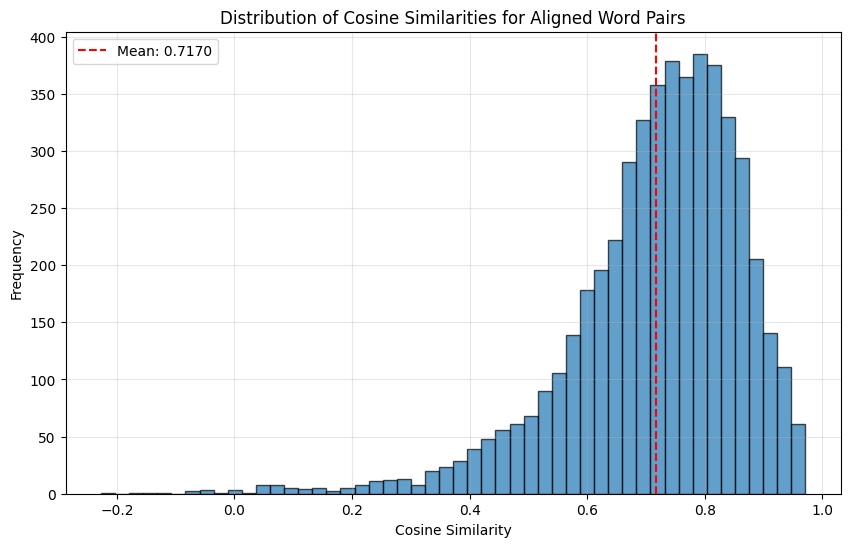


Word pairs with similarity > 0.5: 4597/4999 (92.0%)


In [13]:
# Print evaluation metrics
print("Alignment Quality Evaluation:")
print(f"Mean cosine similarity: {similarities.mean():.4f}")
print(f"Median cosine similarity: {np.median(similarities):.4f}")
print(f"Std deviation: {similarities.std():.4f}")
print(f"Min similarity: {similarities.min():.4f}")
print(f"Max similarity: {similarities.max():.4f}")

# Show some examples
print("\nSample word pairs with their similarities:")
for i in range(min(10, len(en_words))):
    print(f"{en_words[i]:15s} -> {fr_words[i]:15s} : {similarities[i]:.4f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(similarities, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.title('Distribution of Cosine Similarities for Aligned Word Pairs')
plt.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Check percentage of "good" alignments (similarity > threshold)
threshold = 0.5
good_alignments = (similarities > threshold).sum()
print(f"\nWord pairs with similarity > {threshold}: {good_alignments}/{len(similarities)} ({100*good_alignments/len(similarities):.1f}%)")

**Visualize embeddings using t-SNE**

In [14]:
from sklearn.manifold import TSNE

def visualize_embeddings(words, model, title="Word Embeddings"):
    """Visualize embeddings for selected words"""

    # Filter to only words that exist in the model
    valid_words = [w for w in words if pd.notna(w) and w in model]

    # Get vectors for valid words
    vecs = np.array([model[w] for w in valid_words])

    # t-SNE
    perplexity = min(30, len(vecs) - 1)
    reducer = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    coords = reducer.fit_transform(vecs)

    # Plot
    plt.figure(figsize=(12, 8))
    plt.scatter(coords[:, 0], coords[:, 1], alpha=0.6, s=100)

    # Annotate with actual word strings
    for i, word in enumerate(valid_words):
        plt.annotate(word, (coords[i, 0], coords[i, 1]),
                    fontsize=10, alpha=0.8)

    plt.title(title)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.tight_layout()
    plt.show()

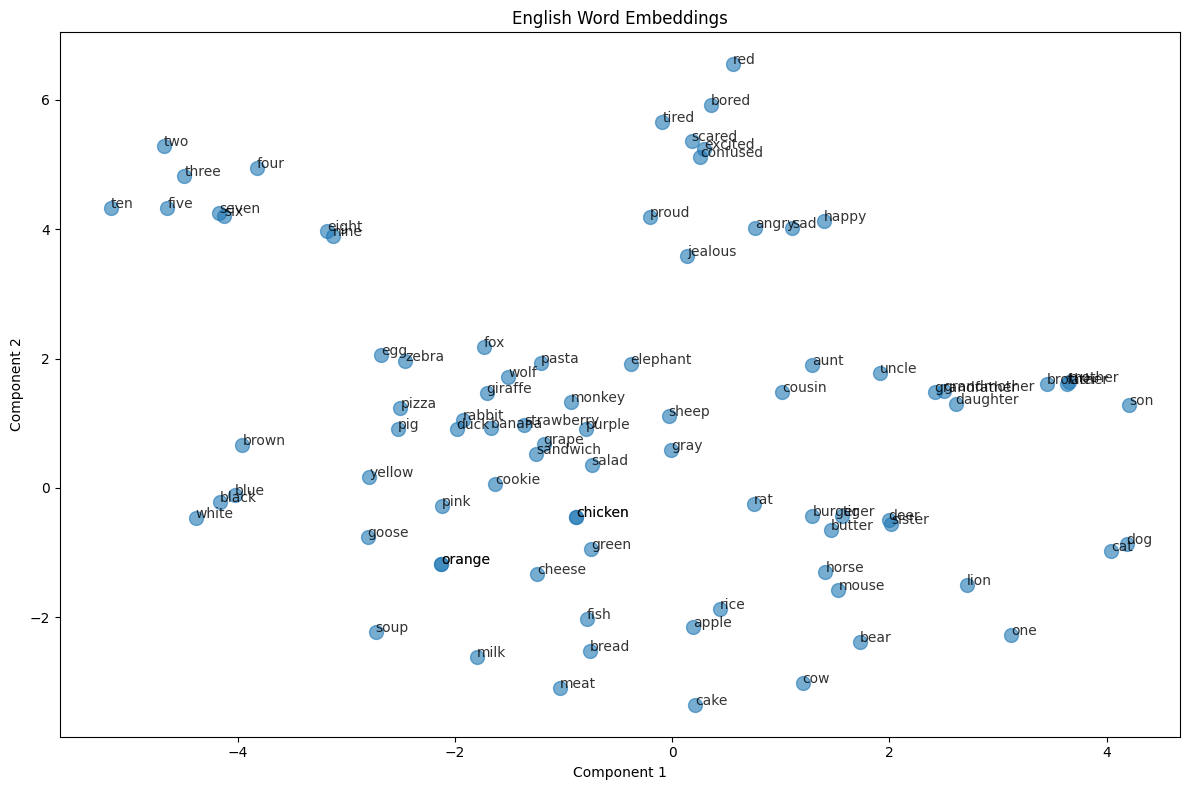

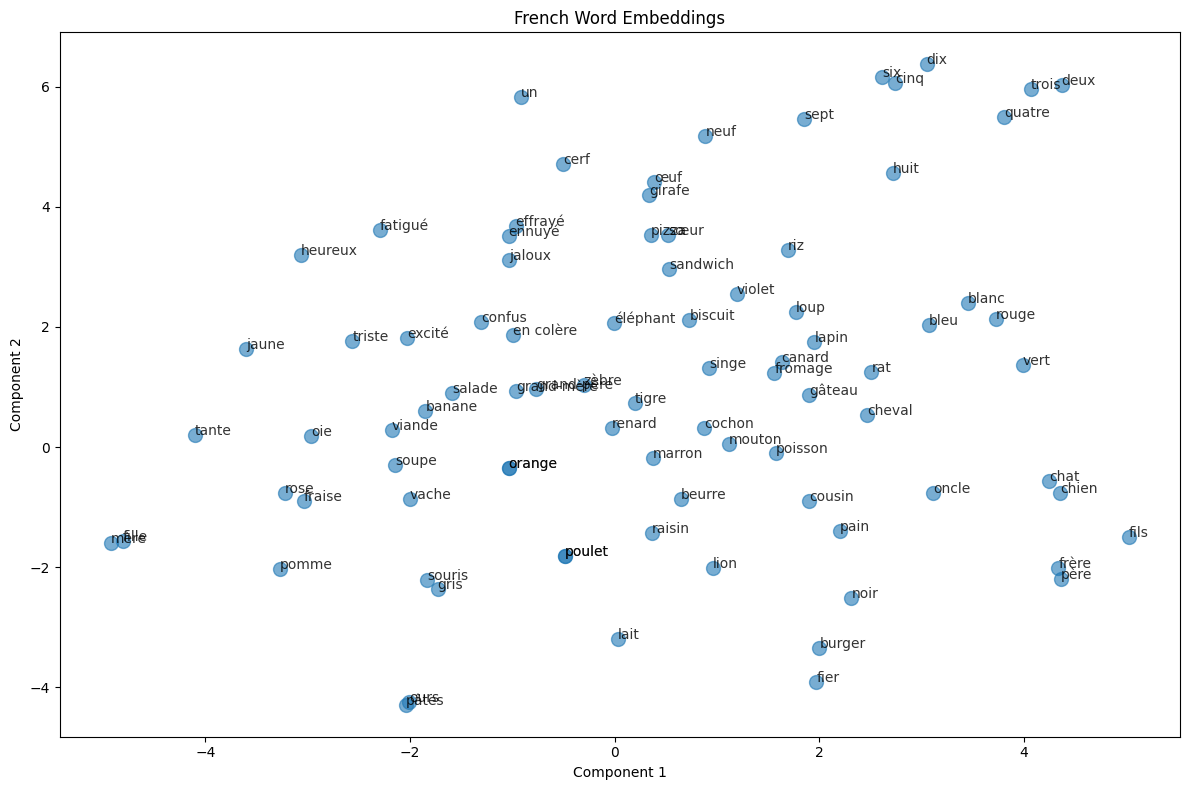

In [15]:
# Use words with clear semantic categories
viz_words_en = [
    'dog', 'cat', 'horse', 'cow', 'pig', 'sheep', 'chicken', 'duck', 'goose',
    'lion', 'tiger', 'bear', 'wolf', 'fox', 'deer', 'rabbit', 'mouse', 'rat',
    'elephant', 'giraffe', 'zebra', 'monkey',

    'bread', 'butter', 'cheese', 'milk', 'egg', 'meat', 'fish', 'chicken',
    'rice', 'pasta', 'pizza', 'burger', 'sandwich', 'salad', 'soup',
    'apple', 'banana', 'orange', 'grape', 'strawberry', 'cake', 'cookie',

    'red', 'blue', 'green', 'yellow', 'black', 'white', 'orange', 'purple',
    'pink', 'brown', 'gray',

    'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'ten',

    'mother', 'father', 'sister', 'brother', 'son', 'daughter', 'grandmother',
    'grandfather', 'aunt', 'uncle', 'cousin',

    'happy', 'sad', 'angry', 'scared', 'excited', 'bored', 'tired', 'proud',
    'jealous', 'confused'
]

viz_words_fr = [
    'chien', 'chat', 'cheval', 'vache', 'cochon', 'mouton', 'poulet', 'canard', 'oie',
    'lion', 'tigre', 'ours', 'loup', 'renard', 'cerf', 'lapin', 'souris', 'rat',
    'éléphant', 'girafe', 'zèbre', 'singe',

    'pain', 'beurre', 'fromage', 'lait', 'œuf', 'viande', 'poisson', 'poulet',
    'riz', 'pâtes', 'pizza', 'burger', 'sandwich', 'salade', 'soupe',
    'pomme', 'banane', 'orange', 'raisin', 'fraise', 'gâteau', 'biscuit',

    'rouge', 'bleu', 'vert', 'jaune', 'noir', 'blanc', 'orange', 'violet',
    'rose', 'marron', 'gris',

    'un', 'deux', 'trois', 'quatre', 'cinq', 'six', 'sept', 'huit', 'neuf', 'dix',

    'mère', 'père', 'sœur', 'frère', 'fils', 'fille', 'grand-mère',
    'grand-père', 'tante', 'oncle', 'cousin',

    'heureux', 'triste', 'en colère', 'effrayé', 'excité', 'ennuyé', 'fatigué', 'fier',
    'jaloux', 'confus'
]

visualize_embeddings(viz_words_en, fasttext_eng.wv, "English Word Embeddings")
visualize_embeddings(viz_words_fr, fasttext_fr.wv, "French Word Embeddings")

**Synonyms/Antonyms**

In [16]:
def analyze_synonyms_antonyms(model, synonyms, antonyms):
    """Analyze similarity between synonyms and antonyms"""

    print("\nSYNONYMS")
    syn_scores = []
    for w1, w2 in synonyms:
        if w1 in model and w2 in model:
            sim = model.similarity(w1, w2)
            syn_scores.append(sim)
            print(f"{w1:15} <-> {w2:15} : {sim:.4f}")
        else:
            print(f"{w1:15} <-> {w2:15} : NOT IN VOCAB")

    print("\nANTONYMS")
    ant_scores = []
    for w1, w2 in antonyms:
        if w1 in model and w2 in model:
            sim = model.similarity(w1, w2)
            ant_scores.append(sim)
            print(f"{w1:15} <-> {w2:15} : {sim:.4f}")
        else:
            print(f"{w1:15} <-> {w2:15} : NOT IN VOCAB")

    if syn_scores and ant_scores:
        print(f"\nSUMMARY")
        print(f"Average Synonym Similarity:  {np.mean(syn_scores):.4f}")
        print(f"Average Antonym Similarity:  {np.mean(ant_scores):.4f}")

In [17]:
synonyms_en = [
    ('happy', 'joyful'), ('sad', 'unhappy'), ('big', 'large'),
    ('small', 'tiny'), ('fast', 'quick'), ('smart', 'intelligent'),
    ('beautiful', 'pretty'), ('angry', 'mad'), ('scared', 'afraid'),
    ('start', 'begin'), ('end', 'finish'), ('help', 'assist')
]
antonyms_en = [
    ('happy', 'sad'), ('big', 'small'), ('hot', 'cold'),
    ('fast', 'slow'), ('good', 'bad'), ('young', 'old'),
    ('light', 'dark'), ('high', 'low'), ('rich', 'poor'),
    ('strong', 'weak'), ('love', 'hate'), ('day', 'night')
]
synonyms_fr = [
    ('heureux', 'joyeux'), ('triste', 'malheureux'), ('grand', 'gros'),
    ('petit', 'minuscule'), ('rapide', 'vite'), ('intelligent', 'malin'),
    ('beau', 'joli'), ('fâché', 'en colère'), ('peur', 'effrayé')
]
antonyms_fr = [
    ('heureux', 'triste'), ('grand', 'petit'), ('chaud', 'froid'),
    ('rapide', 'lent'), ('bon', 'mauvais'), ('jeune', 'vieux'),
    ('clair', 'sombre'), ('haut', 'bas'), ('riche', 'pauvre')
]

analyze_synonyms_antonyms(fasttext_eng.wv, synonyms_en, antonyms_en)
analyze_synonyms_antonyms(fasttext_fr.wv, synonyms_fr, antonyms_fr)


SYNONYMS
happy           <-> joyful          : 0.7755
sad             <-> unhappy         : 0.7727
big             <-> large           : 0.7260
small           <-> tiny            : 0.7256
fast            <-> quick           : 0.7373
smart           <-> intelligent     : 0.7613
beautiful       <-> pretty          : 0.5517
angry           <-> mad             : 0.7145
scared          <-> afraid          : 0.7631
start           <-> begin           : 0.8120
end             <-> finish          : 0.5667
help            <-> assist          : 0.6115

ANTONYMS
happy           <-> sad             : 0.7832
big             <-> small           : 0.7801
hot             <-> cold            : 0.8568
fast            <-> slow            : 0.6972
good            <-> bad             : 0.7929
young           <-> old             : 0.7078
light           <-> dark            : 0.6675
high            <-> low             : 0.5573
rich            <-> poor            : 0.7545
strong          <-> weak           

**Common words across both languages**

In [18]:
def compare_cross_lingual(model_en, model_fr, W):
    """Compare embeddings of translation pairs"""

    translation_pairs = [
        ('hello', 'bonjour'), ('goodbye', 'au revoir'), ('thank you', 'merci'),
        ('dog', 'chien'), ('cat', 'chat'), ('house', 'maison'),
        ('water', 'eau'), ('food', 'nourriture'), ('love', 'amour'),
        ('friend', 'ami'), ('family', 'famille'), ('mother', 'mère'),
        ('father', 'père'), ('happy', 'heureux'), ('sad', 'triste')
    ]

    print(f"CROSS-LINGUAL TRANSLATION PAIR ANALYSIS")

    for en_word, fr_word in translation_pairs:
        if en_word in model_en and fr_word in model_fr:
            # Transform English word into French space
            en_vec_aligned = (model_en[en_word] @ W).reshape(1, -1)
            fr_vec = model_fr[fr_word].reshape(1, -1)

            sim = cosine_similarity(en_vec_aligned, fr_vec)[0][0]
            print(f"{en_word:15} ↔ {fr_word:15} : {sim:.4f}")

In [19]:
# Run Cross-Lingual Analysis
compare_cross_lingual(fasttext_eng.wv, fasttext_fr.wv, W)

CROSS-LINGUAL TRANSLATION PAIR ANALYSIS
hello           ↔ bonjour         : 0.4529
goodbye         ↔ au revoir       : 0.3611
thank you       ↔ merci           : 0.6107
dog             ↔ chien           : 0.7665
cat             ↔ chat            : 0.8572
house           ↔ maison          : 0.8235
water           ↔ eau             : 0.7208
food            ↔ nourriture      : 0.6969
love            ↔ amour           : 0.6150
friend          ↔ ami             : 0.8069
family          ↔ famille         : 0.8549
mother          ↔ mère            : 0.8045
father          ↔ père            : 0.8720
happy           ↔ heureux         : 0.7723
sad             ↔ triste          : 0.7669


**Polysemy**

In [20]:
# Polysemy Analysis Function
def analyze_polysemy(model, polysemous_words):
    """
    Analyze how embeddings handle polysemous words (words with multiple meanings).
    """
    for word, contexts in polysemous_words.items():
        if word not in model:
            print(f"\n'{word}' - NOT IN VOCABULARY")
            continue

        print(f"\n {word}")

        # Calculate similarity to context words
        similarities = []
        for context in contexts:
            if context in model:
                sim = model.similarity(word, context)
                similarities.append((context, sim))
                print(f"  {word} <-> {context:15} : {sim:.4f}")
            else:
                print(f"  {word} <-> {context:15} : NOT IN VOCAB")

        # Find actual nearest neighbors
        if word in model:
            neighbors = model.most_similar(word, topn=10)
            print(f"\n  Top neighbors: {', '.join([w for w, _ in neighbors[:5]])}")

            # Check variance in similarities (high variance = captures multiple meanings)
            if similarities:
                sims = [s for _, s in similarities]
                print(f"  Similarity variance: {np.var(sims):.4f}")

In [21]:
# Test Polysemous Words
polysemous_words_en = {
      'bank': ['money', 'river', 'financial', 'shore', 'deposit', 'loan'],
      'bat': ['baseball', 'animal', 'flying', 'cave', 'mammal', 'sport']
  }
polysemous_words_fr = {
      'voler': ['fly', 'steal', 'avion', 'voleur', 'oiseau', 'crime'],
      'avocat': ['lawyer', 'fruit', 'tribunal', 'guacamole', 'droit', 'légal']
  }
analyze_polysemy(fasttext_eng.wv, polysemous_words_en)
analyze_polysemy(fasttext_fr.wv, polysemous_words_fr)


 bank
  bank <-> money           : 0.5862
  bank <-> river           : 0.6834
  bank <-> financial       : 0.4391
  bank <-> shore           : 0.6905
  bank <-> deposit         : 0.6269
  bank <-> loan            : 0.5350

  Top neighbors: banquet, bankroll, banjo, baa, sandbank
  Similarity variance: 0.0077

 bat
  bat <-> baseball        : 0.6592
  bat <-> animal          : 0.3968
  bat <-> flying          : 0.5642
  bat <-> cave            : 0.5149
  bat <-> mammal          : 0.3955
  bat <-> sport           : 0.6235

  Top neighbors: rowboat, oat, boat, shabbat, rabat
  Similarity variance: 0.0104

 voler
  voler <-> fly             : 0.2709
  voler <-> steal           : 0.4170
  voler <-> avion           : 0.4499
  voler <-> voleur          : 0.6106
  voler <-> oiseau          : 0.5019
  voler <-> crime           : 0.4764

  Top neighbors: branler, gauler, flipper, piler, rigoler
  Similarity variance: 0.0104

 avocat
  avocat <-> lawyer          : 0.3591
  avocat <-> fruit      

**OOV/rare word handling**

In [26]:
# Simple OOV/Rare Word Handling Comparison

def compare_oov_handling_simple():
    """
    Compare how different embedding methods handle out-of-vocabulary (OOV) and rare words.
    """
    # Test words
    common_words = ['hello', 'world', 'good', 'time', 'day']
    rare_words = ['serendipity', 'ephemeral', 'quintessential', 'ubiquitous']
    oov_words = ['xylophrentic', 'blargify', 'quizzlematic', 'snozzleberry']

    all_words = common_words + rare_words + oov_words

    print("OOV/RARE WORD HANDLING COMPARISON")

    results = []

    for word in all_words:
        # Determine category
        if word in common_words:
            category = 'Common'
        elif word in rare_words:
            category = 'Rare'
        else:
            category = 'OOV'

        # Check each model
        onehot = 'Yes' if word in eng_dict else 'No'
        tfidf = 'Yes' if word in tfidf_eng.columns else 'No'
        w2v = 'Yes' if word in word2vec_eng.wv else 'No'
        glove_result = 'Yes' if word in glove else 'No'

        # FastText can generate vectors for OOV
        vec = fasttext_eng.wv[word]
        in_vocab = word in fasttext_eng.wv.key_to_index
        fasttext = 'Yes' if in_vocab else 'Generated'

        results.append({
            'Word': word,
            'Category': category,
            'OneHot': onehot,
            'TFIDF': tfidf,
            'Word2Vec': w2v,
            'GloVe': glove_result,
            'FastText': fasttext
        })

    # Print results
    df = pd.DataFrame(results)
    print(df.to_string(index=False))

    # Summary statistics
    print("SUMMARY")

    for cat in ['Common', 'Rare', 'OOV']:
        cat_df = df[df['Category'] == cat]
        total = len(cat_df)
        print(f"\n{cat} words ({total} words):")

        for model in ['OneHot', 'TFIDF', 'Word2Vec', 'GloVe', 'FastText']:
            found = (cat_df[model].isin(['Yes', 'Generated'])).sum()
            print(f"  {model:12s}: {found}/{total}")

    return df

# Run comparison
results = compare_oov_handling_simple()

OOV/RARE WORD HANDLING COMPARISON


NameError: name 'tfidf_eng' is not defined

**Downstream Task: Multilingual Text Classifier - Language Identification**

In [27]:
# Language Identification using FastText Embeddings

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns

# Prepare dataset for language identification
def prepare_language_dataset(df, sample_size=None):
    """
    Combine English and French sentences into a single dataset with labels
    0 = English, 1 = French
    """
    if sample_size:
        df_sample = df.sample(n=min(sample_size, len(df)), random_state=42)
    else:
        df_sample = df

    # Create English dataset
    english_data = pd.DataFrame({
        'text': df_sample['english'],
        'language': 0  # 0 for English
    })

    # Create French dataset
    french_data = pd.DataFrame({
        'text': df_sample['french'],
        'language': 1  # 1 for French
    })

    # Combine and shuffle
    combined = pd.concat([english_data, french_data], ignore_index=True)
    combined = combined.sample(frac=1, random_state=42).reset_index(drop=True)

    return combined

# Prepare the dataset
lang_df = prepare_language_dataset(df, sample_size=10000)
print(f"Dataset size: {len(lang_df)}")
print(f"English sentences: {(lang_df['language'] == 0).sum()}")
print(f"French sentences: {(lang_df['language'] == 1).sum()}")
print("\nSample data:")
print(lang_df.head(10))

Dataset size: 20000
English sentences: 10000
French sentences: 10000

Sample data:
                                                text  language
0                                            gardele         1
1                        shes up to her neck in debt         0
2                               his teeth were white         0
3                               where is the giraffe         0
4                                   tu nes pas juste         1
5       comment estce que tu sais toutes ces choses          1
6                pourquoi estu toujours si méchante          1
7  youve been gone for so long and i cant remembe...         0
8      elle lui a demandé comment parvenir à la gare         1
9                                  she has nice legs         0


In [28]:
# Create and Get Sentence Embeddings
def get_sentence_embedding(sentence, model):
    """
    Create sentence embedding by averaging word vectors.
    """
    words = sentence.split()
    vectors = []
    for word in words:
        if word in model:
            vectors.append(model[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

X_embeddings = []
for text in lang_df['text']:
    # Get embeddings from both English and French models
    emb_en = get_sentence_embedding(text, fasttext_eng.wv)
    emb_fr = get_sentence_embedding(text, fasttext_fr.wv)
    # Concatenate both embeddings
    X_embeddings.append(np.concatenate([emb_en, emb_fr]))

X_embeddings = np.array(X_embeddings)
y = lang_df['language'].values

print(f"Embedding shape: {X_embeddings.shape}")

Embedding shape: (20000, 200)


In [29]:
# Train Language Classifier

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_embeddings, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

# Train Logistic Regression classifier
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)

Training set: 16000 samples
Test set: 4000 samples



Classification Report:
              precision    recall  f1-score   support

     English     0.9990    0.9980    0.9985      2000
      French     0.9980    0.9990    0.9985      2000

    accuracy                         0.9985      4000
   macro avg     0.9985    0.9985    0.9985      4000
weighted avg     0.9985    0.9985    0.9985      4000


Overall Metrics:
Accuracy:  0.9985
Precision: 0.9985
Recall:    0.9985
F1-Score:  0.9985


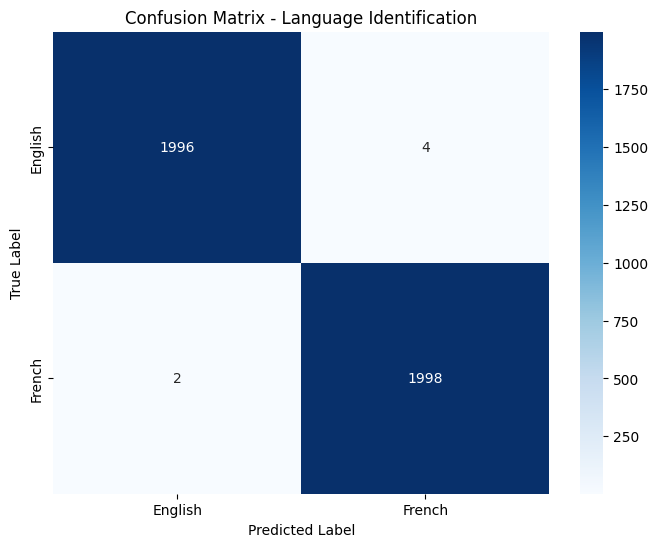

In [30]:
# Evaluate Classifier Performance

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['English', 'French'], digits=4))

# Calculate overall metrics
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, average='weighted')
accuracy = (y_pred == y_test).mean()

print(f"\nOverall Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['English', 'French'],
            yticklabels=['English', 'French'])
plt.title('Confusion Matrix - Language Identification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()